<a href="https://colab.research.google.com/github/junggeyy/gis-notebooks/blob/main/site_suitability_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Site Suitability Analysis: Fire Station for Kathmandu Metropolitian City (KMC)

-- Vickey Ghimire


### Project Overview

This notebook explores a Multi-Criteria Evaluation (MCE) workflow for identifying potential sites for a new fire station in Kathmandu Metropolis.

Given the city's urban density and topography, finding suitable, undeveloped land requires balancing multiple spatial constraints. This project provides a hands-on look at how far we can get with open spatial data to turn raw geography into a decision-support tool.

The workflow integrates different types of spatial data, including road networks, existing fire station coverage, and terrain information. Since these datasets come in different formats, we first process them into a unified, mathematically comparable grid. We then evaluate the landscape using a Weighted Linear Combination (WLC), alongside exclusionary masks that filter out areas already heavily developed or otherwise unsuitable.The result is a shortlist of candidate sites worth exploring on the ground.

### Problem Definition and Criteria Selection

Emergency heavy vehicles, like fire trucks, need relatively flat terrain to operate safely, along with direct access to the drivable road network to ensure rapid response times. To maximize the city's overall emergency coverage, we also want to prioritize locations farther from existing stations. And given KMC's urban sprawl, potential sites need to fall on undeveloped land to avoid costly buyouts and demolitions.

Altogether, we focus on four major criteria: terrain suitability, road accessibility, service coverage, and land availability.



### Setup and Dependencies

In [ ]:
%pip install rioxarray xarray-spatial

In [2]:
import os
import rasterio
import rioxarray
import numpy as np
import xrspatial
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape

### Data Acqusition

We use two primary open-source datasets. OpenStreetMap (OSM) to extract the city's administrative boundaries, the drivable road network, exisiting fire station locations, and open land-use polygons. UCGIS's SRTM dataset for the Digital Elevation Model (DEM) to calculate the gradient of the land.


In [3]:
data_path = '/content/drive/MyDrive/project_srcs/site-suitability-analysis/data'

boundary_file = 'nepal-municipalities.geojson'
roads_file = 'kmc-drivable-roads.geojson'
dem_file = 'ktm-dem.tif'
landuse_file = 'ktm-landuse.geojson'
firestation_file = 'ktm-fire-stations.geojson'

boundary_path = os.path.join(data_path, boundary_file)
roads_path = os.path.join(data_path, roads_file)
dem_path = os.path.join(data_path, dem_file)
landuse_path = os.path.join(data_path, landuse_file)
firestation_path = os.path.join(data_path, firestation_file)

In [4]:
# extracting KMC boundary
nepal_boundary = gpd.read_file(boundary_path)
nepal_boundary = nepal_boundary.set_index('N_ID')
ktm_boundary = nepal_boundary.loc[['kathmandu-kathmandu']]
ktm_boundary

,id,F_ID,NAME,LEVEL,DISTRICT,geometry
N_ID,,,,,,
kathmandu-kathmandu,None,343,Kathmandu,Mahanagarpalika,Kathmandu,"POLYGON ((85.28577 27.68983, 85.28414 27.6927,..."


In [5]:
# Existing firestatons in KMC
ktm_firestation = gpd.read_file(firestation_path)
ktm_firestation

,id,@id,amenity,building,name:en,geometry
0,way/211751501,way/211751501,fire_station,yes,None,"POLYGON ((85.36095 27.69615, 85.36091 27.69608..."
1,node/9722113225,node/9722113225,fire_station,None,Mahanagar Fire Briged and Training Center,POINT (85.36554 27.73176)


In [6]:
# Open landuse in KMC
ktm_open_landuse = gpd.read_file(landuse_path)
ktm_open_landuse = ktm_open_landuse[['@id', 'landuse', 'leisure', 'geometry']]
ktm_open_landuse.head(2)

,@id,landuse,leisure,geometry
0,relation/4572868,grass,None,"POLYGON ((85.35649 27.70081, 85.35645 27.70081..."
1,relation/13833096,grass,None,"MULTIPOLYGON (((85.35509 27.69919, 85.35509 27..."


In [7]:
# Major roads in KMC
ktm_roads = gpd.read_file(roads_path)
ktm_roads = ktm_roads[['@id', 'name', 'surface', 'smoothness', 'lanes', 'maxspeed', 'access', 'geometry']]
ktm_roads.head(2)

,@id,name,surface,smoothness,lanes,maxspeed,access,geometry
0,way/220295107,Te Bahal,asphalt,None,None,None,None,"POLYGON ((85.31182 27.70238, 85.31181 27.70232..."
1,way/500866244,None,None,None,None,None,service,"POLYGON ((85.32289 27.69548, 85.32291 27.69555..."


In [8]:
# DEM for KMC, loaded as DataArray
ktm_dem = rioxarray.open_rasterio(dem_path)

### Data Preprocessing

In this phase, we reproject the default CRS of EPSG:4326, which measures in degrees, to local metric projection of Nepal_Nagarkot_TM (ESRI:102306) for distance calculation in standard meters. Then, we clip the external layers to our exact KMC boundary to keep the analysis focused on our central area.

In [9]:
# reprojecting all crs from EPSG:4326 to ESRI:102306
ktm_roads = ktm_roads.to_crs('ESRI:102306')
ktm_boundary = ktm_boundary.to_crs('ESRI:102306')
ktm_dem = ktm_dem.rio.reproject("ESRI:102306")
ktm_firestation = ktm_firestation.to_crs("ESRI:102306")
ktm_open_landuse = ktm_open_landuse.to_crs("ESRI:102306")

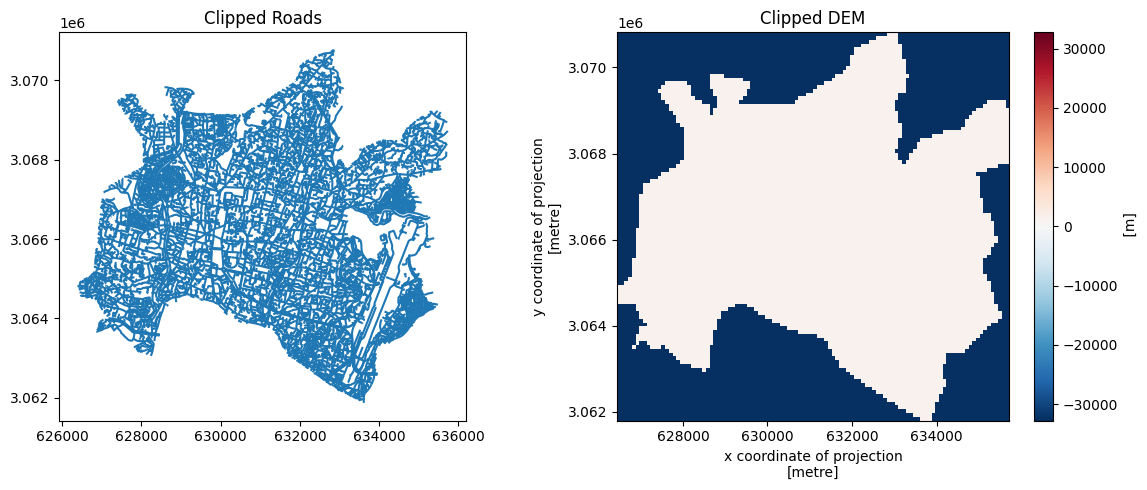

In [10]:
# clipping the roads, DEM, and open land data to be within our ktm_boundary
ktm_road_clipped = ktm_roads.clip(mask=ktm_boundary)
ktm_dem_clipped = ktm_dem.rio.clip(ktm_boundary.geometry)
ktm_open_landuse_clipped = ktm_open_landuse.clip(ktm_boundary)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ktm_road_clipped.plot(ax=ax[0])
ax[0].set_title("Clipped Roads")

ktm_dem_clipped.plot(ax=ax[1])
ax[1].set_title("Clipped DEM")

plt.tight_layout()
plt.show()

### Transformation and Standarization

To mathematically combine our distinct constraints, we need to ensure they follow the same spatial unit. Right now, our vectors (roads, land-use) and rasters (elevation) are fundamentally different data structures. We bridge the gap by converting our discrete vector geometries into continuous raster surfaces, ensuring every dataset perfectly aligns to the exact same pixel grid as our digital elevation model.

In [11]:
from rasterio.features import rasterize

# creating a 2D template from the original DEM
ktm_dem_clipped_2d = ktm_dem_clipped.squeeze()
out_shape = ktm_dem_clipped_2d.rio.shape
transform = ktm_dem_clipped_2d.rio.transform()

# extracting geometries and assigning a burn value of 1
road_shapes = [(geom, 1) for geom in ktm_road_clipped.geometry]
firestation_shapes = [(geom, 1) for geom in ktm_firestation.geometry]
openland_shapes = [(geom, 1) for geom in ktm_open_landuse_clipped.geometry]

# rasterising the vectors into numpy arrays
burned_road_raster = rasterize(road_shapes, out_shape=out_shape,
                               transform=transform, fill=0, all_touched=True)
burned_firestation_raster = rasterize(firestation_shapes, out_shape=out_shape,
                               transform=transform, fill=0, all_touched=True)
burned_openland_raster = rasterize(openland_shapes, out_shape=out_shape,
                               transform=transform, fill=0, all_touched=True)

# converting the arrays into xarray DataArray for spatial operations
coords = ktm_dem_clipped_2d.coords
dims = ktm_dem_clipped_2d.dims

openland_raster = xr.DataArray(burned_openland_raster, coords=coords, dims=dims)
road_raster = xr.DataArray(burned_road_raster, coords=coords,dims=dims)
firestation_raster = xr.DataArray(burned_firestation_raster, coords=coords, dims=dims)

#### Terrain Transformation

The raw DEM pixel values provide the absolute height above seal level. To know the terrain suitability (slope), we  calculate the gradient between each pixel of the DEM and its neighbors to get the maximum rate of elevation change. This provides us with a new raster where the pixel values represent its slope in degrees.
Then, we normalize the raw slope degree values to a suitability score of 1 to 5 so that we have a similar data structure compatible with our other criteria.

In [12]:
# calculate the raw slope in degrees
slope_agg = xrspatial.slope(ktm_dem_clipped_2d, name='slope', method='planar')

# template for the classified slope
classified_slope = xr.zeros_like(slope_agg)

# lower slope value (degrees) scores higher, given the flatness of land
slope_rules = [ (-1, 3, 5), # min value, max value, score
                (3, 7, 4),
                (7, 12, 3),
                (12, 20, 2),
                (20, 90, 1)
              ]
# normalize the raw degrees into scores of 1-5
for min_value, max_value, score in slope_rules:
  mask = (slope_agg > min_value) & (slope_agg <= max_value)
  classified_slope = xr.where(mask, score, classified_slope)
  # numpy -> classified_slope[mask] = score

# since the rasterizing process overwrote NaNs -> 0s, we use the original DEM
# mask to convert pixels outside the KMC city boundary back to NaNs.
classified_slope = xr.where(np.isnan(slope_agg), np.nan, classified_slope)

#### Proximity Transformation

At this point, our roads and firestation rasters only know where these structures exist, but we also need to know the spatial cost of getting there. For this, we run a proximity algorithm to calculate the distance from every single pixel in KMC to the nearest road and existing fire station.

Then, just like the terrain operation, we classify these continuous distances into our standard 1 to 5 scores.

In [13]:
# calculate continuous Euclidean distance
road_distance_agg = xrspatial.proximity(road_raster)
firestation_distance_agg = xrspatial.proximity(firestation_raster)

# templates for the classified proximity
classified_road_proximity = xr.zeros_like(road_distance_agg)
classified_firestation_proximity = xr.zeros_like(firestation_distance_agg)

# areas closer to road access scores higher
road_rules = [(-1, 100, 5), # min value, max value, score
              (100, 300, 4),
              (300, 500, 3),
              (500, 800, 2),
              (800, 9999, 1)
              ]

# areas further away from existing stations score higher
firestation_rules = [(-1, 1000, 1),
                  (1000, 2000, 2),
                  (2000, 3000, 3),
                  (3000, 4000, 4),
                  (4000, 99999, 5)
                  ]
# classifies road proximity
for min_value, max_value, score in road_rules:
  mask = (road_distance_agg > min_value) & (road_distance_agg <= max_value)
  classified_road_proximity = xr.where(mask, score, classified_road_proximity)

# classifies firestation proximity
for min_value, max_value, score in firestation_rules:
  mask = (firestation_distance_agg > min_value) & (firestation_distance_agg <= max_value)
  classified_firestation_proximity = xr.where(mask, score, classified_firestation_proximity)

# converting pixels outside the KMC city boundary back to NaNs
classified_road_proximity = xr.where(np.isnan(slope_agg), np.nan, classified_road_proximity)
classified_firestation_proximity = xr.where(np.isnan(slope_agg), np.nan, classified_firestation_proximity)

### Overlay Analysis and Selection


With all our criteria standardized into overlapping matrices, we bring the model together using a Weighted Linear Combination (WLC). By assigning proportional weights to our terrain, road access, and service coverage constraints, we calculate a raw suitability score, ranging 1-5, for every square meter of the city.

We then multiply this combined matrix by our exclusionary open-land mask. This boolean operation removes any pixels that happen to fall on existing buildings or developed neighborhoods, leaving only the viable open spaces.

In [14]:
# weighted linear combinaton
W_slope = 0.3
W_road_proximity = 0.4
W_firestation_proximity = 0.3
threshold = 4.5

# using WLC for scored criteria
suitability = (W_slope * classified_slope) + (W_road_proximity *
                  classified_road_proximity) + (W_firestation_proximity *
                  classified_firestation_proximity)

# multiplying by the openland_raster to turn any built-up land into NaN, to exclude them
final_suitability = suitability * openland_raster

# filtering to include only those areas over the chosen threshold
final_suitability = xr.where(final_suitability >= threshold, final_suitability, np.nan)

Once we have the final suitability scores for open land pixels in the city, we run a vectorization algorithm to translate those pixels into real-world geometry. This allows us to actually view and understand these spots in the real world.

In [16]:
from rasterio.features import shapes

vectors = shapes(final_suitability.values, transform=final_suitability.rio.transform())

# at this point, 'vectors' is a generator object which we have to consume
feature_list = []
for geom, value in vectors:
  if not np.isnan(value):
    poly = shape(geom)
    feature_list.append({
        "geometry": poly.centroid,
        "suitability_score": value,
        "area": poly.area
    })

# converting the sites list into GDF
final_sites_gdf = gpd.GeoDataFrame(feature_list, crs="ESRI:102306")
final_sites_gdf.head()

,geometry,suitability_score,area
0,POINT (631909.949 3069588.956),4.7,15312.686453
1,POINT (631603.698 3069238.954),4.7,30625.372906
2,POINT (628847.431 3068320.198),5.0,7656.343227
3,POINT (631384.946 3068232.698),4.7,7656.343227
4,POINT (631866.199 3068232.698),4.7,15312.686453


### Results & Visualization

In [17]:
# filtering the dataframe to only include areas >= 3000 sq m and sorting them.
final_sites_gdf = final_sites_gdf[final_sites_gdf['area'] >= 3000]
final_sites_gdf = final_sites_gdf.sort_values(
    by=['suitability_score', 'area'], ascending=[False, False]).reset_index(drop=True)

final_sites_gdf['Display Area'] = final_sites_gdf['area'].round(2).astype(str) + ' sq m'
final_sites_gdf['Suitability Score'] = final_sites_gdf['suitability_score'].round(2)

final_sites_gdf.head()

,geometry,suitability_score,area,Display Area,Suitability Score
0,POINT (630435.902 3066388.456),5.0,99532.461945,99532.46 sq m,5.0
1,POINT (629953.119 3064979.269),5.0,84219.775492,84219.78 sq m,5.0
2,POINT (630080.393 3065480.408),5.0,84219.775492,84219.78 sq m,5.0
3,POINT (628903.113 3064517.902),5.0,84219.775492,84219.78 sq m,5.0
4,POINT (629912.021 3067211.858),5.0,45938.059359,45938.06 sq m,5.0


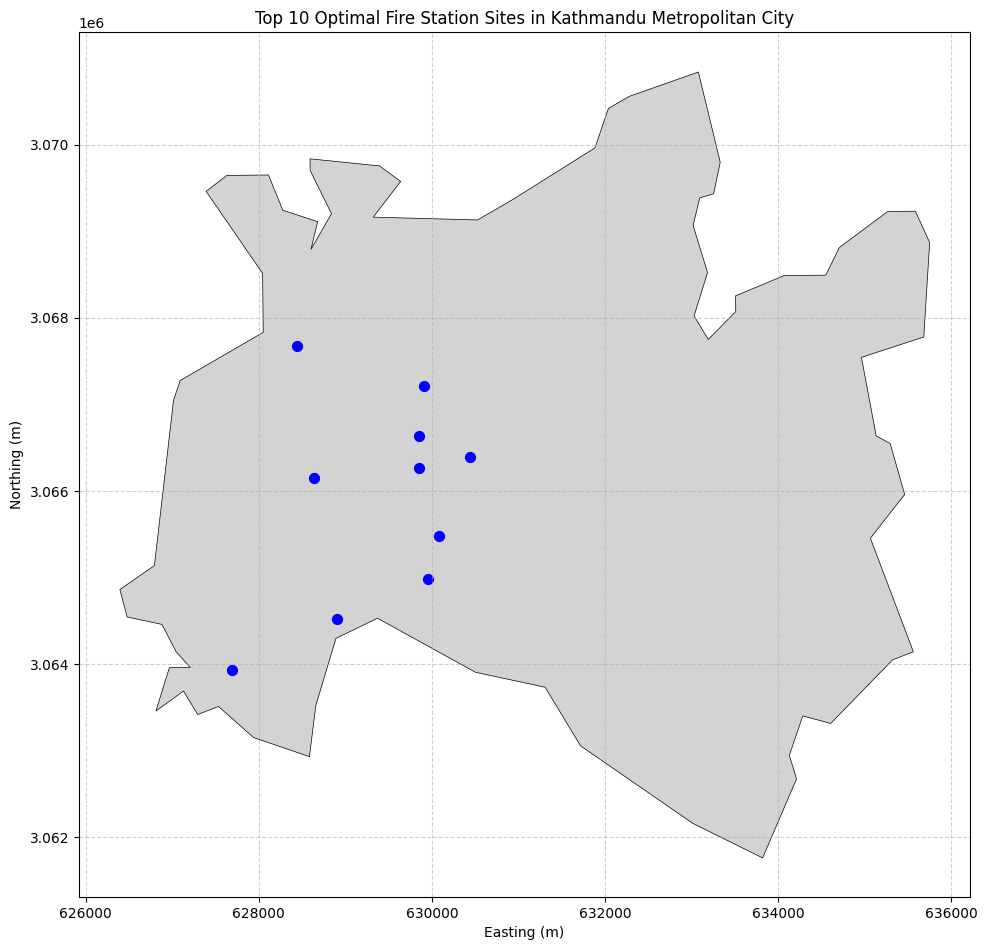

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# KMC boundary as the base layer
ktm_boundary.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)

# top 10 final suitability overlay
final_sites_gdf.head(10).plot(
    ax=ax,
    marker='o',
    color='blue',
    markersize=50
)

ax.set_title('Top 10 Optimal Fire Station Sites in Kathmandu Metropolitan City')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
final_sites_gdf.explore(
    column="suitability_score",
    cmap="plasma_r",
    tooltip=["Suitability Score", "Display Area"],
    tooltip_kwds=dict(aliases=["Suitability Score:", "Usable Area:"]),
    marker_kwds=dict(radius=8, fillOpacity=0.8, color="black", weight=1),
    legend=False
    )

In [48]:
# reprojecting back to EPSG:4326 before exporting for web maps
export_gdf = final_sites_gdf.to_crs("EPSG:4326")

export_gdf.to_file('ktm_optimal_fire_stations.geojson', driver='GeoJSON')

### Acknowledgement of limitations

While this pipeline successfully isolates viable open land based on our selected criteria, it is important to acknowledge the limitations of both the data used and the mathematical model in a real urban planning context.

The analysis relies entirely on community-driven data, so information may occasionally be outdated or lack the legal nuance of official city zoning. The foundational Weighted Linear Combination model does not account for dynamic urban variables like  traffic congestion or one-way networks. Furthermore, we would also need to factor in multiple complex constraints such as the financial cost, soil stability, exclusionary buffer zones around sensitive areas, and so on.



